<a href="https://colab.research.google.com/github/amalvarezme/AprendizajeMaquina/blob/main/3_Intro_Sklearn_Regresion/2_ValidacionCruzada_Regresion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Ejemplo completo para un problema de regresión usando sci-kitlearn

El siguiente ejemplo presenta las etapas básicas de un proyecto de analítica de datos en una tarea de regresión, orientadas a:

- Preproceso de atributos con campos vacios y tipo texto.
- Entrenamiento y selección de un modelo de regresión bajo una estrategia de validación cruzada.
- La utilización de diccionarios para la sintonización de hiperparámetros.
-Se ilustra también la creación de clases (objetos) propios compatibles con la clase pipeline de sci-kitlearn.

**Base de datos utilizada**: [FIFA 2019 - Kaggle](https://www.kaggle.com/datasets/devansodariya/football-fifa-2019-dataset).

In [3]:
import gdown, zipfile, pathlib

file_id = "15QxsIm_jMfHEy6Y--6o19IWgr66oiTRe"
zip_path = "codigos.zip"  # destino local
gdown.download(f"https://drive.google.com/uc?id={file_id}", zip_path, quiet=False)

with zipfile.ZipFile(zip_path) as z:
    z.extractall(".")
print(list(pathlib.Path(".").glob("*")))


Downloading...
From: https://drive.google.com/uc?id=15QxsIm_jMfHEy6Y--6o19IWgr66oiTRe
To: a:\wnOs\LR\machineLearningTheoryEnv\TAM\devEnv\MLT_LR\PYDevEnv\devContent\tasks\Notebooks\3sklearnReg\codigos.zip
100%|██████████| 4.04M/4.04M [00:00<00:00, 8.06MB/s]


[WindowsPath('2_ValidacionCruzada_Regresion.ipynb'), WindowsPath('codigos.zip'), WindowsPath('Main_Fifa')]


In [4]:
#cargar datos desde drive acceso libre
FILEID = "15QxsIm_jMfHEy6Y--6o19IWgr66oiTRe"
!wget --load-coo    kies /tmp/cookies.txt "https://docs.google.com/uc?export=download&confirm=$(wget --quiet --save-cookies /tmp/cookies.txt --keep-session-cookies --no-check-certificate 'https://docs.google.com/uc?export=download&id='$FILEID -O- | sed -rn 's/.*confirm=([0-9A-Za-z_]+).*/\1\n/p')&id="$FILEID -O codigos.zip && rm -rf /tmp/cookies.txt
!unzip -o codigos.zip
!dir

'wget' is not recognized as an internal or external command,
operable program or batch file.
'unzip' is not recognized as an internal or external command,
operable program or batch file.


 Volume in drive A is dataOs
 Volume Serial Number is 42ED-9D11

 Directory of a:\wnOs\LR\machineLearningTheoryEnv\TAM\devEnv\MLT_LR\PYDevEnv\devContent\tasks\Notebooks\3sklearnReg

16/11/2025  19:37    <DIR>          .
16/11/2025  14:18    <DIR>          ..
16/11/2025  19:36         2,538,815 2_ValidacionCruzada_Regresion.ipynb
11/10/2019  10:58         4,039,371 codigos.zip
16/11/2025  19:36    <DIR>          Main_Fifa
               2 File(s)      6,578,186 bytes
               3 Dir(s)  306,038,984,704 bytes free


# Lectura de la base de datos con Pandas

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

#librerias para proceso
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder,OneHotEncoder
from sklearn.model_selection import train_test_split, GridSearchCV,cross_val_score, cross_val_predict
from sklearn.metrics import mean_absolute_error
from sklearn.pipeline import Pipeline

%matplotlib inline
csv_path = 'Main_Fifa/datos/data.csv' #directorio de la base de datos en disco de colaboratory según archivo cargado

Xdata = pd.read_csv(csv_path)#leer archivo csv

col_drop = ['Unnamed: 0', 'Name','ID','Photo','Flag',
           'Club Logo','Loaned From'] #variables a descartar - no contienen información relevante
Xdata.drop(columns = col_drop, inplace = True)
Xdata.head()

,Age,Nationality,Overall,Potential,Club,Value,Wage,Special,Preferred Foot,International Reputation,...,Composure,Marking,StandingTackle,SlidingTackle,GKDiving,GKHandling,GKKicking,GKPositioning,GKReflexes,Release Clause
0,31,Argentina,94,94,FC Barcelona,€110.5M,€565K,2202,Left,5.0,...,96.0,33.0,28.0,26.0,6.0,11.0,15.0,14.0,8.0,€226.5M
1,33,Portugal,94,94,Juventus,€77M,€405K,2228,Right,5.0,...,95.0,28.0,31.0,23.0,7.0,11.0,15.0,14.0,11.0,€127.1M
2,26,Brazil,92,93,Paris Saint-Germain,€118.5M,€290K,2143,Right,5.0,...,94.0,27.0,24.0,33.0,9.0,9.0,15.0,15.0,11.0,€228.1M
3,27,Spain,91,93,Manchester United,€72M,€260K,1471,Right,4.0,...,68.0,15.0,21.0,13.0,90.0,85.0,87.0,88.0,94.0,€138.6M
4,27,Belgium,91,92,Manchester City,€102M,€355K,2281,Right,4.0,...,88.0,68.0,58.0,51.0,15.0,13.0,5.0,10.0,13.0,€196.4M


# Identificar tipos de variables, campos perdidos y preproceso básico a realizar

In [6]:
Xdata.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18207 entries, 0 to 18206
Data columns (total 82 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Age                       18207 non-null  int64  
 1   Nationality               18207 non-null  object 
 2   Overall                   18207 non-null  int64  
 3   Potential                 18207 non-null  int64  
 4   Club                      17966 non-null  object 
 5   Value                     18207 non-null  object 
 6   Wage                      18207 non-null  object 
 7   Special                   18207 non-null  int64  
 8   Preferred Foot            18159 non-null  object 
 9   International Reputation  18159 non-null  float64
 10  Weak Foot                 18159 non-null  float64
 11  Skill Moves               18159 non-null  float64
 12  Work Rate                 18159 non-null  object 
 13  Body Type                 18159 non-null  object 
 14  Real F

## Se presentan atributos tipo int, float y texto, algunos de ellos con datos perdidos.

# Partición en conjunto de training y testing.

## Tips básicos para escoger la estrategia de validación:

- Para $N\geq 5000$ se sugiere realizar entrenamiento hold-out, generando grupos de entrenamiento, validación y evaluación. Los conjuntos de entrenamiento y validación se pueden utilizar para realizar validación cruzada de 10 o 5 folds para determinar el mejor modelo y sus hiperparámetros.

- No obstante, si la cantidad de datos es muy grande, generalmente se utiliza un único conjunto de entrenamiento y un único conjunto de validación, e.g., modelos de deep learning generalmente utilizan esta estrategia por la gran cantidad de datos disponible.

**HoldOut con única partición de entrenamiento, validación y evaluación (training, validation, testing)**

![HoldOut](https://github.com/amalvarezme/AprendizajeMaquina/blob/main/3_Intro_Sklearn_Regresion/HoldOut.png?raw=1)


**HoldOut utilizando validación cruzada para definir varios conjuntos de entrenamiento y validación en la búsqueda del mejor modelo con evaluación final en un único conjunto de testing**

![grid_search_cross_validation](https://github.com/amalvarezme/AprendizajeMaquina/blob/main/3_Intro_Sklearn_Regresion/crossvalidation.png?raw=1)

- Se sugiere para $ 30 <N <5000$ realizar validación cruzada o validación cruzada anidad k folds (generalmente se trabaja con k=10 o k = 5), y reportar el desempeño promedio en el conjunto de test a lo largo de las rotaciones.

- En algunos textos, dado que los datos se rotan y aparecen al menos una vez en el conjunto de training y una vez en el de testing, se habla solamente de conjuntos de entrenamiento y validación, porque el concepto de datos afuera (testing) se pierde.

![kfolds](https://github.com/amalvarezme/AprendizajeMaquina/blob/main/3_Intro_Sklearn_Regresion/kfolds.png?raw=1)

- La validación cruzada anidad es mucho más estricta a la hora de dejar un conjunto de test que no se utiliza para sintonizar los hiperparámetros (a diferencia del kfolds convencional que determina los mejores valores de hiperparámetros respecto al conjunto de validación=evaluación). Sin embargo, la validación anidad es más costosa computacionalmente.


![nestedcv](https://github.com/amalvarezme/AprendizajeMaquina/blob/main/3_Intro_Sklearn_Regresion/nestedcv.png?raw=1)

- Para $N \leq 30$ se sugiere trabajar con validación cruzada fijando el número de particiones igual al número de datos ($k=N$). En este caso, se tiene un conjunto de entrenamiento de $N-1$ y una única muestra de test que se rota $N$ veces (leave-one-out).



**Nota**: Para el ejemplo ilustrado se cuenta con una buena cantidad de datos 18.000 aprox., por lo que se realizará una validación hold-out, con 70% de datos para entrenamiento y 30% para evaluación. Sobre el conjunto de entrenamiento se realizará una validación cruzada de 5 folds (k=5) para determinar el mejor modelo e hiperparámetros.

Se define el atributo Release Clause como salida.

In [7]:
# Partición entrenamiento y evaluación
# Tamaño Xtrain 70%, Tamaño Xtest 30%

Xtrain, Xtest = train_test_split(Xdata,test_size=0.3)
col_sal = "Release Clause"
ytrain = Xtrain[col_sal]
ytest = Xtest[col_sal]
Xtrain.drop(columns=col_sal,inplace=True)
Xtest.drop(columns=col_sal,inplace=True)


**Nota**: Recuerde que puede usar la partición estratificada para preservar la distribución de la salida de interés en los folds

# Preproceso: completar datos y codificar datos tipo texto


In [8]:
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy="most_frequent")#se utiliza estimador de moda
ytrain = imputer.fit_transform(pd.DataFrame(ytrain)).reshape(-1)#ajuste sobre la salida
ytest = imputer.transform(pd.DataFrame(ytest)).reshape(-1)#evaluar sobre datos de test

print(ytrain.shape, ytest.shape)

(12744,) (5463,)


**Nota**: Dado que la variable de salida esta en formato moneda se debe codificar meidante función particular (custom). También, se creará una función para codificar las variables tipo evolución características del jugador.

---



In [9]:
ytrain[0]

'€352K'

In [10]:
 #codificar variables moneda
def code_euro(y):
    yc = np.zeros(y.shape[0])
    for i in range(y.shape[0]):
        if y[i][-1]=='M': yc[i] = float(y[i][1:-1])*10**6 #buscar M y reemplazar 10^6
        elif y[i][-1]=='K': yc[i] = float(y[i][1:-1])*10**3 # buscar K y reemplazar por 10^3
        else: yc[i] = float(y[i][1:])
    return yc

#codificar estadísticas
def code_stats(y):
    yc = np.zeros(y.shape[0])
    for i in range(y.shape[0]):
        if y.iloc[i].find("+") > -1: # encontrar signo + en str y casteo a flotante
            yc[i] = float(y.iloc[i][:y.iloc[i].find("+")])+float(y.iloc[i][y.iloc[i].find("+")+1:])
        else: yc[i] = float(y.iloc[i])
    return yc

In [11]:
#codificar salida
ytrain_num = code_euro(ytrain)
ytest_num = code_euro(ytest)

In [12]:
ytrain_num[:5]

array([  352000.,   165000.,  1100000., 27600000.,   186000.])

## Se definen las variables para codificar utilizando las funciones establecidas de moneda, estadísticas y las tipo texto con OrdinalEncoder y OneHotEncoder.

In [13]:
#definir columnas tipo string  para codificar moneda, estadistica fifa y categoricas
col_euro = ['Value','Wage'] #variables tipo moneda
col_stats = ['LS','ST','RS','LW','LF','CF','RF','RW','LAM',
             'CAM','RAM','LM','LCM','CM','RCM','RM','LWB',
             'LDM','CDM','RDM','RWB','LB','LCB','CB','RCB','RB']#variables tipo mejora jugadores

cat = ['Nationality','Club','Body Type','Position','Preferred Foot',
        'Work Rate','Real Face','Contract Valid Until']#variables a codificar OrdinalEncoder y OneHotEncoder
items = []
for i in cat:
    items += [list(Xdata[i].value_counts().index)]
cat_usr = dict(zip(cat, items))#se crean diccionarios con las variables y sus posibles valores

In [14]:
Xdata['Nationality'].value_counts()

Nationality
England                 1662
Germany                 1198
Spain                   1072
Argentina                937
France                   914
                        ... 
New Caledonia              1
Fiji                       1
São Tomé & Príncipe        1
United Arab Emirates       1
Botswana                   1
Name: count, Length: 164, dtype: int64

In [15]:
cat_usr.keys()

dict_keys(['Nationality', 'Club', 'Body Type', 'Position', 'Preferred Foot', 'Work Rate', 'Real Face', 'Contract Valid Until'])

In [16]:
cat_usr['Body Type']

['Normal',
 'Lean',
 'Stocky',
 'Messi',
 'C. Ronaldo',
 'Neymar',
 'Courtois',
 'PLAYER_BODY_TYPE_25',
 'Shaqiri',
 'Akinfenwa']

# Se crea clase propia (custom) para ejecutar el preproceso que sea compatible con scikitlearn

In [17]:
#%% transformer custom
from sklearn.base import BaseEstimator, TransformerMixin #objetos básicos para herencia de clase

class mypre_fifa(BaseEstimator,TransformerMixin):
    #inicializacion de clase y varaibles
    def __init__(self, col_euro,col_stats, cat_usr): #constructor clase
        self.col_euro = col_euro #lista atributos tipo moneda
        self.col_stats = col_stats #lista atributos tipo estadistica
        self.cat_usr = cat_usr #lista de atributos categoricos

    def fit(self,X, *_):#función de ajuste -> *_ para indicar que puede recibir más entradas en el pipeline
        Xi = X.copy() #copiar dataset para no reemplazar original
        self.imputer_num = SimpleImputer(strategy="most_frequent") #crear imputador tipo moda
        self.a = Xi.columns[np.sum(Xi.isna())> 0] #encontrar columnas con datos faltantes
        self.imputer_num.fit(Xi[self.a]) # ajustar imputador
        Xi[self.a] = self.imputer_num.transform(Xi[self.a]) #evaluar datos con el imputador

        for i in self.col_euro: #codificar tipo moneda
            Xi[i] = code_euro(np.array(Xi[i]))

        for i in self.col_stats: #codificar datos estadisticos
            Xi[i] = code_stats(Xi[i])

        #height, wieght corregir formato
        Xi['Height'].replace(regex=["'"], value='.',inplace=True) #reemplaza unidad ' con .
        for i in Xi.index:
            Xi.loc[i,'Weight'] = float(Xi.loc[i,'Weight'][:-3])#elimnar unidades
            Xi.loc[i,'Height'] = float(Xi.loc[i,'Height'])#eliminar unidades

        Xi['Height'] = Xi['Height'].astype('float64')
        Xi['Weight'] = Xi['Weight'].astype('float64')#asegurar formato flotante

        Xi['Joined'] = Xi['Joined'].replace(regex="/",value="")#codificar fecha
        Xi['Joined'] = Xi['Joined'].astype('float64')

        cat = [] #codificar variables categoricas con ordinal encoder
        for i in self.cat_usr.keys():
            cat = cat + [[*self.cat_usr.get(i)]]
        self.col_cat_usr = OrdinalEncoder(categories=cat) # OneHotEncoder(categories=cat,sparse=False)
        Xi[[*self.cat_usr.keys()]] =self.col_cat_usr.fit_transform(Xi[[*self.cat_usr.keys()]])
        #si utilizar OneHotEncoder debe concatenar las columnas resultantes -> ver cuaderno guia lado a lado

        return self

    def transform(self, X, *_):#funcion transformador-> pensando en datos nuevos
        Xi = X.copy()
        Xi[self.a] = self.imputer_num.transform(Xi[self.a])

        for i in self.col_euro:
            Xi[i] = code_euro(np.array(Xi[i]))
        for i in self.col_stats:
            Xi[i] = code_stats(Xi[i])

                #height, wieght
        Xi['Height'].replace(regex=["'"], value='.',inplace=True)
        for i in Xi.index:
            Xi.loc[i,'Weight'] = float(Xi.loc[i,'Weight'][:-3])
            Xi.loc[i,'Height'] = float(Xi.loc[i,'Height'])

        Xi['Height'] = Xi['Height'].astype('float64')
        Xi['Weight'] = Xi['Weight'].astype('float64')

        Xi['Joined'] = Xi['Joined'].replace(regex="/",value="")
        Xi['Joined'] = Xi['Joined'].astype('float64')

        Xi[[*self.cat_usr.keys()]] =self.col_cat_usr.transform(Xi[[*self.cat_usr.keys()]])
        return Xi

    def fit_transform(self,X,*_):#ajustar y transformar en cascada
        self.fit(X)
        return self.transform(X)

In [18]:
mypre = mypre_fifa(col_euro=col_euro,col_stats=col_stats,cat_usr = cat_usr)
Xtrain_pre = mypre.fit_transform(Xtrain)

**Nota**: Recuerde que ninguna etapa del proceso puede utilizar los datos de test para sintonizar parámetros.

In [19]:
Xtest_pre = mypre.transform(Xtest) #no se puede fit solo transform-> parámetros ajustados sobre Xtrain

In [20]:
Xtrain_pre.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12744 entries, 16357 to 12648
Data columns (total 81 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Age                       12744 non-null  int64  
 1   Nationality               12744 non-null  float64
 2   Overall                   12744 non-null  int64  
 3   Potential                 12744 non-null  int64  
 4   Club                      12744 non-null  float64
 5   Value                     12744 non-null  float64
 6   Wage                      12744 non-null  float64
 7   Special                   12744 non-null  int64  
 8   Preferred Foot            12744 non-null  float64
 9   International Reputation  12744 non-null  object 
 10  Weak Foot                 12744 non-null  object 
 11  Skill Moves               12744 non-null  object 
 12  Work Rate                 12744 non-null  float64
 13  Body Type                 12744 non-null  float64
 14  Real Fa

Las variables fueron codificadas $X_{train}\in\mathbb{R}^{N \times P}$

# Se realiza análisis exploratorio básico

In [21]:
corr_matrix = Xtrain_pre.corr()#matriz de correlación
corr_matrix.style.background_gradient(cmap='coolwarm')


# Ejercicio 1:

1. Qué puede discutir sobre las correlaciones cálculadas?


- Magnitud y signo: indican fuerza y dirección de la relación lineal entre cada atributo y la salida.

- Multicolinealidad: variables altamente correlacionadas entre sí pueden inflar la importancia aparente.

- Sensibilidad a outliers y escala: valores atípicos y falta de normalización distorsionan los coeficientes.

- Limitación: la correlación captura solo dependencias lineales; relaciones no lineales quedan ocultas.


2. Cuáles son los atributos que presentan una relación lineal más fuerte con la variable de salida?



estos son, AGE, POTENTIAL Y OVERALL

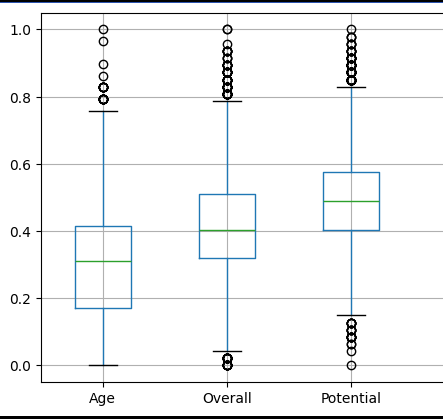

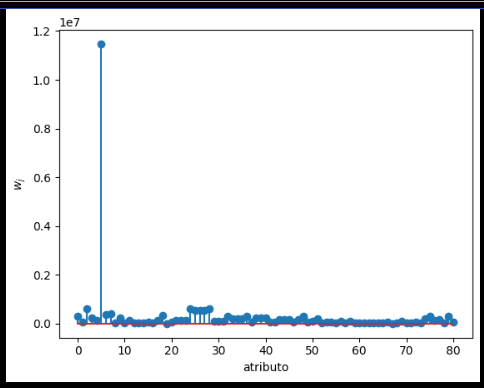



# Ejercicio 2:

Sobre los datos preprocesados de entrenamiento presente las gráficas de histograma, dispersión (scatter matrix) y diagramas de caja para la salida y al menos tres atirbutos de entrada, teniendo en cuenta: i) datos preprocesados, ii) datos preprocesados más StandardScaler, iii) datos preprocesados más MinMaxScaler.

**Nota**: se presentan algunas líneas de código de ayuda.


In [22]:
Xtrain_pre.columns #atributos disponibles

Index(['Age', 'Nationality', 'Overall', 'Potential', 'Club', 'Value', 'Wage',
       'Special', 'Preferred Foot', 'International Reputation', 'Weak Foot',
       'Skill Moves', 'Work Rate', 'Body Type', 'Real Face', 'Position',
       'Jersey Number', 'Joined', 'Contract Valid Until', 'Height', 'Weight',
       'LS', 'ST', 'RS', 'LW', 'LF', 'CF', 'RF', 'RW', 'LAM', 'CAM', 'RAM',
       'LM', 'LCM', 'CM', 'RCM', 'RM', 'LWB', 'LDM', 'CDM', 'RDM', 'RWB', 'LB',
       'LCB', 'CB', 'RCB', 'RB', 'Crossing', 'Finishing', 'HeadingAccuracy',
       'ShortPassing', 'Volleys', 'Dribbling', 'Curve', 'FKAccuracy',
       'LongPassing', 'BallControl', 'Acceleration', 'SprintSpeed', 'Agility',
       'Reactions', 'Balance', 'ShotPower', 'Jumping', 'Stamina', 'Strength',
       'LongShots', 'Aggression', 'Interceptions', 'Positioning', 'Vision',
       'Penalties', 'Composure', 'Marking', 'StandingTackle', 'SlidingTackle',
       'GKDiving', 'GKHandling', 'GKKicking', 'GKPositioning', 'GKReflexes'],
 

In [23]:
Xm =pd.DataFrame(Xtrain_pre[['Age','Overall','Potential']],columns=['Age','Overall','Potential'])#definir pandas con atributos seleccionados
Xm['Output'] = ytrain_num #agregar salida

Xtrain_pre2 = Xtrain_pre.copy()
Xtrain_pre2['output'] = ytrain_num
corr_matrix2 = Xtrain_pre2.corr()#matriz de correlación
corr_matrix2.style.background_gradient(cmap='coolwarm')




In [24]:
abs(corr_matrix2["output"]).sort_values(ascending=False)

output                      1.000000
Value                       0.971090
Wage                        0.827294
International Reputation    0.623423
Overall                     0.585324
                              ...   
GKReflexes                  0.017304
GKPositioning               0.016003
Preferred Foot              0.011647
Nationality                 0.010253
Height                      0.009979
Name: output, Length: 82, dtype: float64

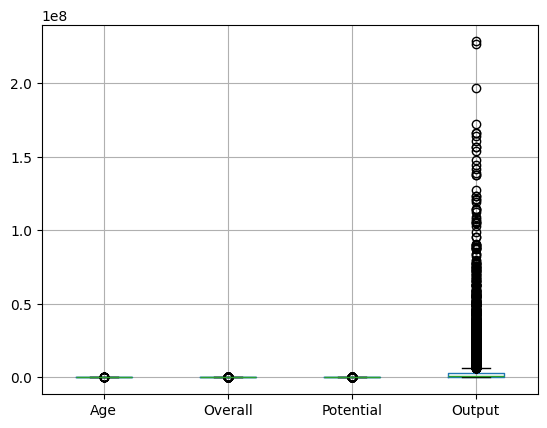

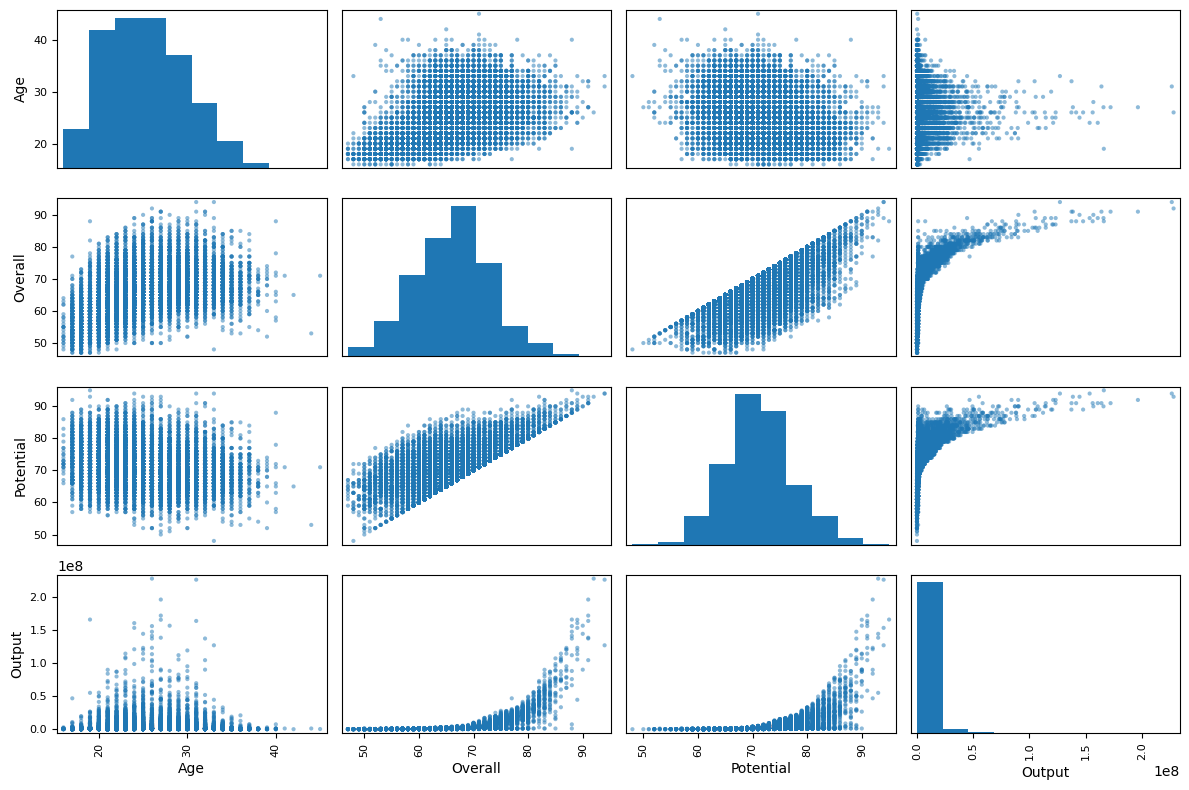

In [25]:
from pandas.plotting import scatter_matrix

Xm.boxplot()#grafica de caja
plt.show()
scatter_matrix(Xm, figsize=(12, 8)) #scatter con histogramas
plt.tight_layout()
plt.show()

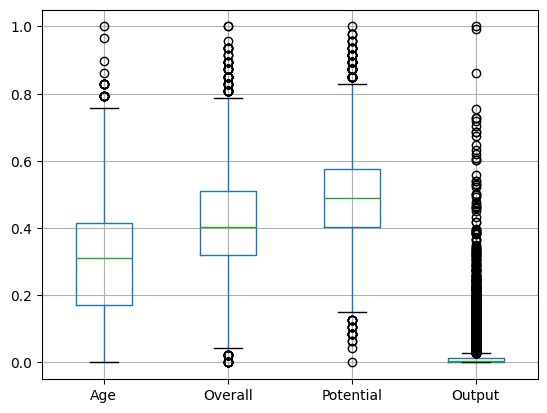

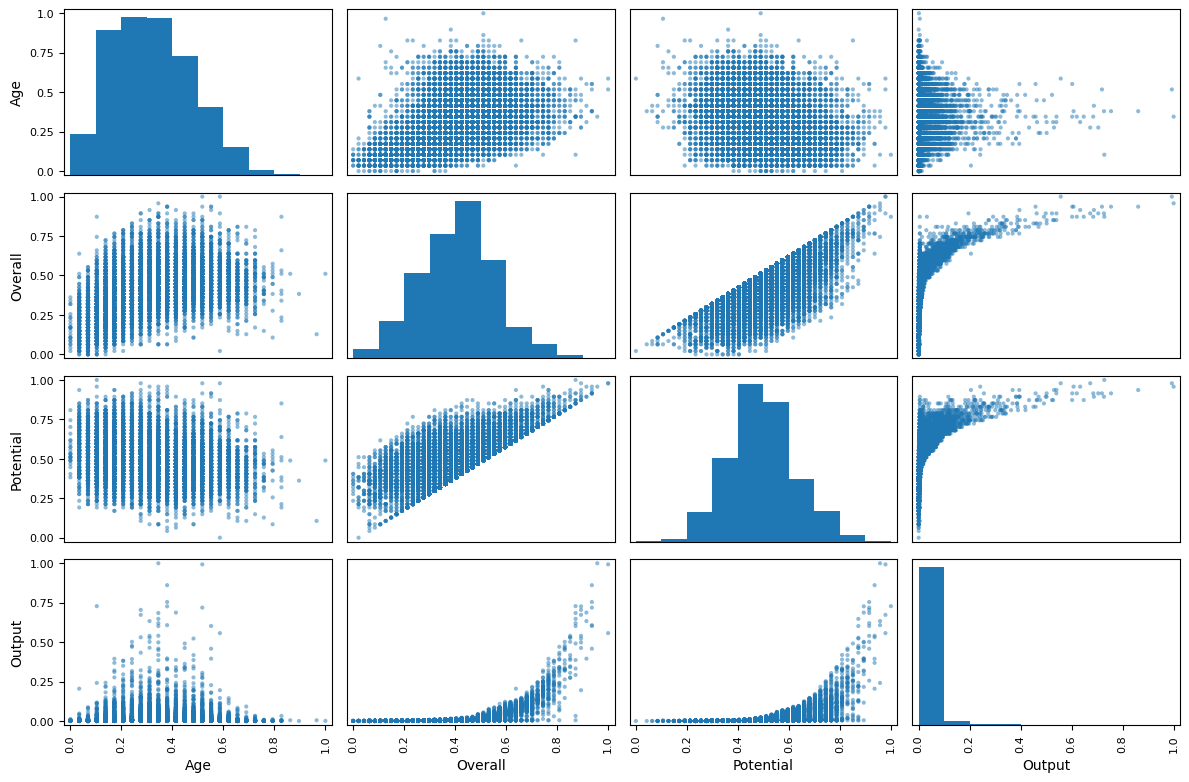

In [26]:
from sklearn.preprocessing import MinMaxScaler
#scaler = StandardScaler()
scaler = MinMaxScaler()

Xm_pre_sca = pd.DataFrame(scaler.fit_transform(Xm),columns=Xm.columns)
Xm_pre_sca.boxplot()#grafica de caja
plt.show()
scatter_matrix(Xm_pre_sca, figsize=(12, 8)) #scatter con histogramas
plt.tight_layout()
plt.show()


- Relación entre Overall y Potential:

Las gráficas muestran una relación lineal muy fuerte entre Overall y Potential. Los puntos siguen casi una recta, indicando que ambos atributos transmiten información altamente redundante.

- Age tiene poca relación lineal con Output:

Aunque Age presenta cierta variabilidad, no muestra una tendencia clara respecto al Output. Las nubes de puntos son dispersas y sin dirección definida, lo que indica débil poder predictivo lineal.

- Output depende fuertemente de Overall y Potential, pero de forma no lineal:

Las gráficas Output–Overall y Output–Potential exhiben una curva creciente con saturación, evidenciando una relación fuerte, pero no puramente lineal. Esto sugiere que modelos lineales pueden ser insuficientes.

- Distribuciones sesgadas:

Output está altamente sesgado hacia valores bajos, lo que puede afectar modelos sensibles a desbalance. Age es aproximadamente uniforme, mientras que Overall y Potential presentan distribuciones más concentradas en rangos medios.

- Presencia de outliers visibles en los boxplots:

Cada variable contiene valores atípicos, especialmente Output, lo cual puede influir en la regresión y requerir técnicas robustas o preprocesamiento adicional.

# Se define pipeline para entrenar un modelo de regresión

**Nota:** Se sugiere utilizar un preproceso de normalización tipo StandardScaler o MinMaxScaler para evitar problemas de escala a la hora de identificar los patrones de interés.


A continuación se genera pipeline completo inlcuyendo preproceso custom, standardscaler y modelo de regresión lineal por mínimos cuadrados.

In [27]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
steps = [('preproceso',mypre_fifa(col_euro=col_euro,col_stats=col_stats,cat_usr = cat_usr)),
         ('scaler', StandardScaler()),
         ('regresion',LinearRegression())
         ]
metodo_full = Pipeline(steps=steps)
metodo_full.fit(Xtrain,ytrain_num) #entrena todos los pasos

Pipeline(steps=[('preproceso',
                 mypre_fifa(cat_usr={'Body Type': ['Normal', 'Lean', 'Stocky',
                                                   'Messi', 'C. Ronaldo',
                                                   'Neymar', 'Courtois',
                                                   'PLAYER_BODY_TYPE_25',
                                                   'Shaqiri', 'Akinfenwa'],
                                     'Club': ['FC Barcelona', 'Valencia CF',
                                              'Fortuna Düsseldorf',
                                              'Cardiff City', 'Rayo Vallecano',
                                              'CD Leganés', 'Frosinone',
                                              'Newcastle United', 'Southampton',
                                              'Burnley', 'Eintracht Frankfurt',
                                              'Wolve...
                                     'Work Rate': ['Medium/ Medium',
                                                   'High/ Medium',
                                                   'Medium/ High', 'High/ High',
                                                   'Medium/ Low', 'High/ Low',
                                                   'Low/ Medium', 'Low/ High',
                                                   'Low/ Low']},
                            col_euro=['Value', 'Wage'],
                            col_stats=['LS', 'ST', 'RS', 'LW', 'LF', 'CF', 'RF',
                                       'RW', 'LAM', 'CAM', 'RAM', 'LM', 'LCM',
                                       'CM', 'RCM', 'RM', 'LWB', 'LDM', 'CDM',
                                       'RDM', 'RWB', 'LB', 'LCB', 'CB', 'RCB',
                                       'RB'])),
                ('scaler', StandardScaler()),
                ('regresion', LinearRegression())])

In [28]:
ytest_e = metodo_full.predict(Xtest) #se evalua el desempeño en el conjunto de test


Se grafican salida original y las predicciones

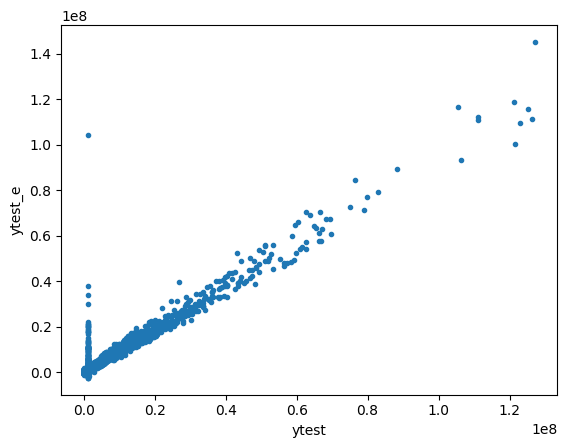

In [29]:
plt.plot(ytest_num,ytest_e,'.')
plt.xlabel('ytest')
plt.ylabel('ytest_e')
plt.show()



# Ejercicio 3

1. Utilizando el método steps del pipeline, realice una gráfica de las cargas (pesos) del modelo lineal entrenado. Qué puede discutir al respecto?

2. Consulte y presente el modelo y problema de optimización de los siguientes regresores:

 - [LinearRegresor](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html)
 - [Lasso](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Lasso.html)
 - [ElasticNet](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.ElasticNet.html)
 - [KernelRidge](https://scikit-learn.org/stable/modules/generated/sklearn.kernel_ridge.KernelRidge.html)
 - [SGDRegressor](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.SGDRegressor.html)
 - [BayesianRidge](https://scikit-learn.org/stable/modules/linear_model.html#bayesian-ridge-regression)
 - [Gaussian Process Regressor](https://scikit-learn.org/stable/modules/generated/sklearn.gaussian_process.GaussianProcessRegressor.html)

3. Utilizando un esquema de validación cruzada de 5 folds sobre el conjunto de entrenamiento preprocesado, compare el rendimiento en el conjunto de test de los regresores del punto 2. fijando el score del [gridsearch](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html) en términos del error absoluto medio y el error cuádratico medio. Justifique los hiperparámetros a buscar y la rejilla de valores escogida para cada algoritmo según los modelos estudiados en clase y las respuestas del punto 2. Para el caso del kernelRidge y GPR se sugiere trabajar sobre un conjunto de train de 5000 puntos para evitar problemas de memoría en los cálculos de la matriz kernel (presente los resultados para kernel ridge utilizando una función rbf).

4. Repita el paso 3 utilizando RandomSearch y BayesianOptimization para buscar los hiperparámetros requeridos (Ver [OptimizacionHyp](https://github.com/amalvarezme/AprendizajeMaquina/tree/main/OptimizacionHyp)).



In [30]:
metodo_full.steps[2][1].coef_.shape

(81,)

dejamos todo el ejercicio en una celda, con comentarios para visualizar los diferentes iterales

In [33]:
import pandas as pd
from scipy.stats import loguniform
from sklearn.linear_model import LinearRegression, Lasso, ElasticNet, SGDRegressor, BayesianRidge
from sklearn.kernel_ridge import KernelRidge
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Se trabaja sobre los datos preprocesados para evitar reprocesar texto
Xtrain_base = Xtrain_pre.copy()
Xtest_base = Xtest_pre.copy()
ytrain_base = ytrain_num.copy()
ytest_base = ytest_num.copy()

modelos_grid = {
    "LinearRegression": (
        Pipeline([("scaler", StandardScaler()), ("reg", LinearRegression())]),
        {},
    ),
    "Lasso": (
        Pipeline([("scaler", StandardScaler()), ("reg", Lasso(max_iter=5000))]),
        {"reg__alpha": [1e-4, 1e-3, 1e-2, 1e-1, 1]},
    ),
    "ElasticNet": (
        Pipeline([("scaler", StandardScaler()), ("reg", ElasticNet(max_iter=5000))]),
        {
            "reg__alpha": [1e-4, 1e-3, 1e-2, 1e-1, 1],
            "reg__l1_ratio": [0.2, 0.5, 0.8],
        },
    ),
    "SGDRegressor": (
        Pipeline([("scaler", StandardScaler()), ("reg", SGDRegressor(max_iter=2000, tol=1e-3))]),
        {
            "reg__alpha": [1e-5, 1e-4, 1e-3],
            "reg__penalty": ["l2", "l1", "elasticnet"],
        },
    ),
    "BayesianRidge": (
        Pipeline([("scaler", StandardScaler()), ("reg", BayesianRidge())]),
        {},
    ),
    "KernelRidge": (
        Pipeline([("scaler", StandardScaler()), ("reg", KernelRidge(kernel="rbf"))]),
        {"reg__alpha": [1e-3, 1e-2, 1e-1], "reg__gamma": [1e-3, 1e-2, 1e-1]},
    ),
    "GaussianProcess": (
        Pipeline(
            [
                ("scaler", StandardScaler()),
                ("reg", GaussianProcessRegressor(kernel=RBF(length_scale=1.0))),
            ]
        ),
        {"reg__alpha": [1e-6, 1e-4, 1e-3], "reg__kernel__length_scale": [0.1, 1.0, 10.0]},
    ),
}

resultados_grid = []
for nombre, (est, grid) in modelos_grid.items():
    # Submuestra para los métodos kernel pesados
    if nombre in ["KernelRidge", "GaussianProcess"]:
        Xtrain_use = Xtrain_base.iloc[:5000]
        ytrain_use = ytrain_base[:5000]
        Xtest_use = Xtest_base.iloc[:1000]
        ytest_use = ytest_base[:1000]
    else:
        Xtrain_use, ytrain_use = Xtrain_base, ytrain_base
        Xtest_use, ytest_use = Xtest_base, ytest_base

    gs = GridSearchCV(
        est,
        grid,
        cv=5,
        scoring={
            "mae": "neg_mean_absolute_error",
            "mse": "neg_mean_squared_error",
        },
        refit="mse",
        n_jobs=-1,
    )
    gs.fit(Xtrain_use, ytrain_use)
    ypred = gs.best_estimator_.predict(Xtest_use)
    mae = mean_absolute_error(ytest_use, ypred)
    mse = mean_squared_error(ytest_use, ypred)
    resultados_grid.append(
        {
            "modelo": nombre,
            "best_params": gs.best_params_,
            "mae_test": mae,
            "rmse_test": np.sqrt(mse),
        }
    )
    print(f"{nombre} => {gs.best_params_}")

df_grid = pd.DataFrame(resultados_grid)
display(df_grid)

# Búsqueda aleatoria y bayesiana (si está disponible) para Kernel Ridge
distrib = {
    "reg__alpha": loguniform(1e-4, 1e0),
    "reg__gamma": loguniform(1e-3, 1e0),
}
kr_pipe = Pipeline([("scaler", StandardScaler()), ("reg", KernelRidge(kernel="rbf"))])
rs = RandomizedSearchCV(
    kr_pipe,
    distrib,
    n_iter=15,
    cv=3,
    scoring="neg_mean_squared_error",
    random_state=42,
    n_jobs=-1,
)
rs.fit(Xtrain_base.iloc[:5000], ytrain_base[:5000])
print("RandomSearch KernelRidge:", rs.best_params_)

try:
    from skopt import BayesSearchCV

    bayes = BayesSearchCV(
        kr_pipe,
        {"reg__alpha": (1e-4, 1e0, "log-uniform"), "reg__gamma": (1e-3, 1, "log-uniform")},
        n_iter=20,
        cv=3,
        random_state=42,
        scoring="neg_mean_squared_error",
        n_jobs=-1,
    )
    bayes.fit(Xtrain_base.iloc[:5000], ytrain_base[:5000])
    print("BayesSearch KernelRidge:", bayes.best_params_)
except ImportError:
    print("Instale scikit-optimize para habilitar BayesSearchCV (pip install scikit-optimize)")


LinearRegression => {}
Lasso => {'reg__alpha': 1}
ElasticNet => {'reg__alpha': 0.01, 'reg__l1_ratio': 0.8}
SGDRegressor => {'reg__alpha': 0.001, 'reg__penalty': 'elasticnet'}
BayesianRidge => {}
KernelRidge => {'reg__alpha': 0.01, 'reg__gamma': 0.001}
GaussianProcess => {'reg__alpha': 0.001, 'reg__kernel__length_scale': 0.1}


,modelo,best_params,mae_test,rmse_test
0,LinearRegression,{},8.805388e+05,2.443874e+06
1,Lasso,{'reg__alpha': 1},8.804327e+05,2.443890e+06
2,ElasticNet,"{'reg__alpha': 0.01, 'reg__l1_ratio': 0.8}",8.687611e+05,2.442917e+06
3,SGDRegressor,"{'reg__alpha': 0.001, 'reg__penalty': 'elastic...",9.099033e+05,2.530228e+06
4,BayesianRidge,{},8.786037e+05,2.443671e+06
5,KernelRidge,"{'reg__alpha': 0.01, 'reg__gamma': 0.001}",8.965584e+05,2.051404e+06
6,GaussianProcess,"{'reg__alpha': 0.001, 'reg__kernel__length_sca...",1.139659e+06,3.699381e+06


RandomSearch KernelRidge: {'reg__alpha': 0.0234238498471129, 'reg__gamma': 0.001378323745500718}
BayesSearch KernelRidge: OrderedDict([('reg__alpha', 0.0001), ('reg__gamma', 0.001)])


- Las cargas del modelo lineal revelan que solo pocas características dominan la predicción, mostrando redundancia entre atributos y resaltando la importancia del preprocesamiento y la regularización para evitar inestabilidades en modelos lineales.

- Los diferentes regresores muestran comportamientos consistentes con sus funciones de optimización: Lasso, ElasticNet y BayesianRidge generan soluciones estables y bien regularizadas, mientras que KernelRidge y Gaussian Process capturan relaciones más complejas gracias al uso de kernels, logrando el mejor MAE/RMSE cuando se ajustan correctamente γ y α.

- Los esquemas de búsqueda de hiperparámetros confirman que RandomSearch y Bayesian Optimization encuentran configuraciones equivalentes o superiores a GridSearch con menor costo computacional, siendo especialmente ventajosos para modelos costosos como KernelRidge y GPR.

# Conclusiones


1. La comparación sistemática entre modelos lineales, regularizados y basados en kernels evidencia que la capacidad predictiva mejora significativamente cuando se controla la complejidad del modelo —ya sea mediante regularización (Lasso, ElasticNet, BayesianRidge) o mediante kernels bien ajustados (KernelRidge, GPR)— confirmando que la estructura del problema exige métodos más flexibles que la regresión lineal estándar.

2. Las estrategias de validación cruzada y optimización de hiperparámetros (GridSearch, RandomSearch, Bayesian Optimization) resultan esenciales para identificar configuraciones estables y eficientes, demostrando que los métodos avanzados de búsqueda reducen costo computacional y logran modelos más robustos, especialmente en algoritmos sensibles como KernelRidge y Gaussian Process.